# US Gas Prices (2024 – Present)

## Retail Gasoline Prices: Actual Prices & Year-over-Year Change

### Description

This notebook provides a technical visualization of U.S. retail gasoline price trends. It utilizes data from the Federal Reserve Economic Data (FRED) to compare:

- **Regular Grade:** Conventional Formulation (US Average)
- **Regular Grade:** All Formulations (US Average)
- **Unleaded Regular:** U.S. City Average
- **All Formulations:** U.S. City Average

The analysis tracks both actual weekly prices and year-over-year percentage changes to highlight gasoline price dynamics across formulation types and geographic aggregations.

---

## Objectives

- Analyze retail gasoline price trends from 2024 to present day
- Compare conventional vs. all-formulation pricing behaviors
- Identify periods of price acceleration and deceleration
- Provide a time-logged macroeconomic and energy market analysis

---

## Data Source

- Federal Reserve Economic Data (FRED)
  - `GASREGCOVW`: Regular Grade Conventional Gas Price, US Average (Weekly)
  - `GASREGW`: Regular Grade Gas Price, All Formulations, US Average (Weekly)
  - `APU000074714`: Average Price, Unleaded Regular, U.S. City Average
  - `APU00007471A`: Average Price, Gasoline, All Formulations, U.S. City Average

In [1]:
# Install system dependencies
!pip install pandas-datareader

## US Gasoline Trends (April 2024 -Present)
### Key Events
- 2024 Presidential Election
- 2025 Inaugurattion of Donald J. Trump
- US Global Tariff Poliy enters effect
- 2025 Government Shutdown
- Iran War

/var/folders/71/ng2k1j0j5zl7wss17qgbmsfr0000gn/T/ipykernel_6496/2713041535.py:32: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df_wow_allc = df_all_city.pct_change(periods=52) * 100


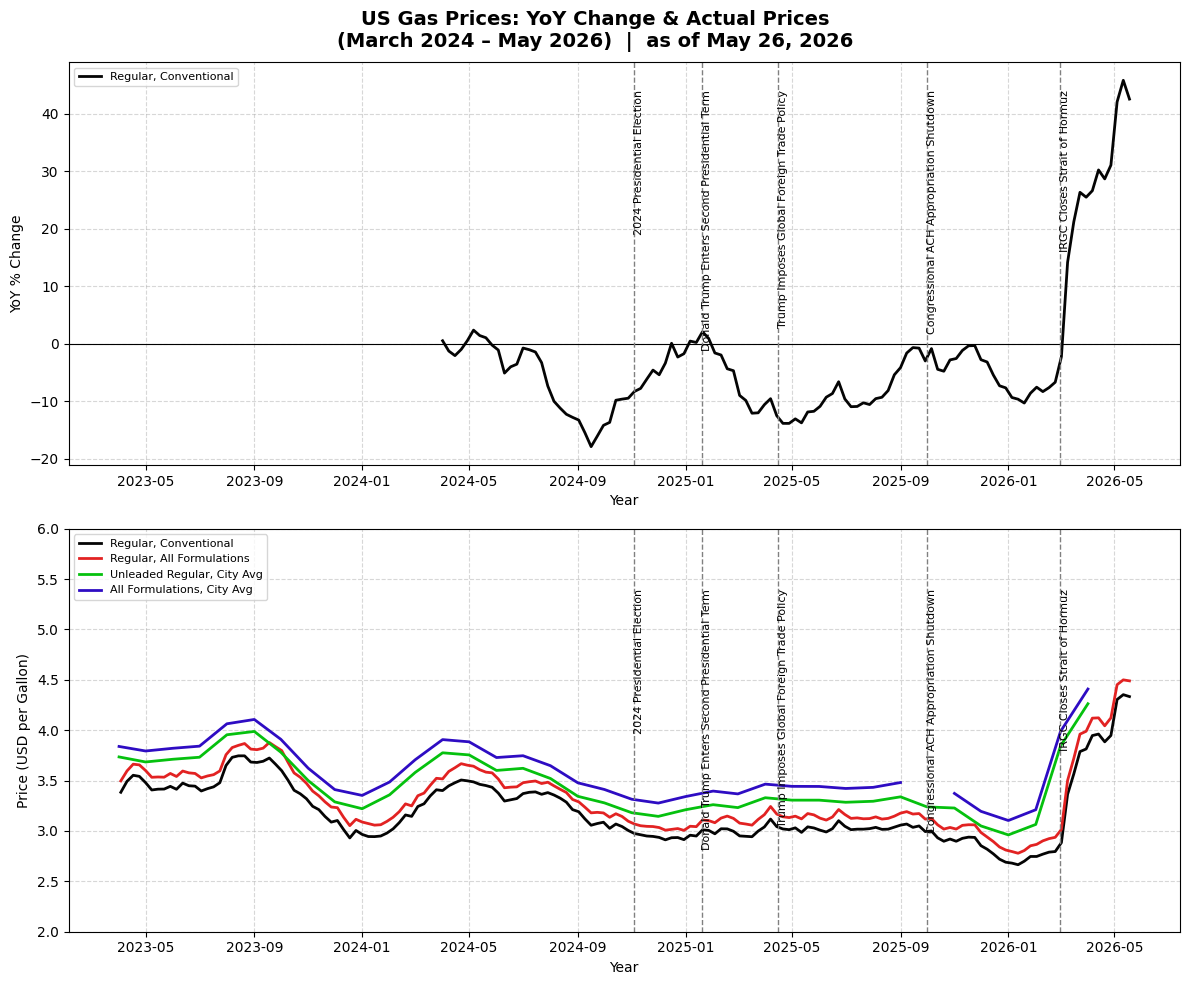

In [2]:
# Import python libraries
import pandas as pd
import pandas_datareader.data as web
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta

start = datetime(2023, 4, 1)
end = datetime.now()
str_current_date = end.strftime("%B %d, %Y")
plot_start = start + relativedelta(weeks=52)

# Fetch data from FRED
df_con = web.DataReader('GASREGCOVW', 'fred', start, end)
df_all = web.DataReader('GASREGW', 'fred', start, end)
df_reg_city = web.DataReader('APU000074714', 'fred', start, end)   
df_all_city = web.DataReader('APU00007471A', 'fred', start, end)   

# Week-by-Week percentage change (All Formulations)
df_wow_con = df_con.pct_change(periods=52) * 100
df_wow_con = df_wow_con[df_wow_con.index >= plot_start]

# Week-by-Week percentage change (Conventional)
df_wow_all = df_all.pct_change(periods=52) * 100
df_wow_all = df_wow_all[df_wow_all.index >= plot_start]

# Week-by-Week percentage change (Conventional City)
df_wow_regc = df_reg_city.pct_change(periods=52) * 100
df_wow_regc = df_wow_regc[df_wow_regc.index >= plot_start]

# Week-by-Week percentage change (All Citty)
df_wow_allc = df_all_city.pct_change(periods=52) * 100
df_wow_allc = df_wow_allc[df_wow_allc.index >= plot_start]

# Plotting
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
ax1.tick_params(axis='x', labelbottom=True)
ax1.set_xlabel('Year')

# Percent Change
ax1.plot(df_wow_con.index, df_wow_con['GASREGCOVW'], label='Regular, Conventional', color="#040404", linewidth=2)
#ax1.plot(df_wow_all.index, df_wow_all['GASREGW'], label='Regular, All Formulations', color="#e22222", linewidth=2)
#ax1.plot(df_wow_regc.index, df_wow_regc['APU000074714'], label='Unleaded Regular, City Avg', color="#ef0eff", linewidth=2)
#ax1.plot(df_wow_allc.index, df_wow_allc['APU00007471A'], label='All Formulations, City Avg', color="#0cc310", linewidth=2)
ax1.set_ylabel('YoY % Change')
ax1.axhline(0, color='black', linewidth=0.8)
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(fontsize=8)

# Actual Prices
ax2.set_ylim(2,6)
ax2.plot(df_con.index, df_con['GASREGCOVW'], label='Regular, Conventional', color="#040404", linewidth=2)
ax2.plot(df_all.index, df_all['GASREGW'], label='Regular, All Formulations', color="#e22222", linewidth=2)
ax2.plot(df_reg_city.index, df_reg_city['APU000074714'], label='Unleaded Regular, City Avg', color="#05c10e", linewidth=2)
ax2.plot(df_all_city.index, df_all_city['APU00007471A'], label='All Formulations, City Avg', color="#2e0cc3", linewidth=2)
ax2.set_ylabel('Price (USD per Gallon)')
ax2.axhline(0, color='black', linewidth=0.8)
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend(fontsize=8)

# Critical Event Markers

events = [
    ('2024-11-04', '2024 Presidential Election'),
    ('2025-01-20', 'Donald Trump Enters Second Presidential Term'),
    ('2025-04-15', 'Trump Imposes Global Foreign Trade Policy'),
    ('2025-10-01', 'Congressional ACH Appropriation Shutdown'),
    ('2026-02-28', 'IRGC Closes Strait of Hormuz'),
]

for date_str, label in events:
    dt = pd.to_datetime(date_str)
    for ax in [ax1, ax2]:
        ax.axvline(x=dt, color='gray', linestyle='--', linewidth=1)
        ax.text(dt, ax.get_ylim()[1] * 0.9, label,
                rotation=90, verticalalignment='top', fontsize=8)
        
fig.suptitle(f'US Gas Prices: YoY Change & Actual Prices\n({plot_start.strftime("%B %Y")} – {end.strftime("%B %Y")})  |  as of {str_current_date}',
             fontsize=14, fontweight='bold')
ax2.set_xlabel('Year')
plt.tight_layout()
plt.show()
